## import library

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

## load data

In [ ]:
# Load dataset
df = pd.read_csv('dataset/dataset_paprika_batu_scheduled.csv')

# Fungsi untuk generate kebutuhan air (Liter/m2)
def hitung_kebutuhan_air(row):
    fase = row['Fase']
    k_tanah = row['Kelembapan_Tanah']
    
    # Aturan dasar: (Batas Kelembapan Ideal - Kelembapan Aktual) * Multiplier Kebutuhan Air
    if fase == 0:
        # Fase Vegetatif / Awal
        batas_ideal = 65.0
        multiplier = 0.05
    elif fase == 1:
        # Fase Pembungaan (Contoh)
        batas_ideal = 70.0
        multiplier = 0.08
    else:
        # Fase Pembuahan / Akhir (Fase 2 ke atas)
        batas_ideal = 75.0
        multiplier = 0.12
        
    # Kalau tanah masih lebih basah dari batas ideal, nggak perlu disiram (0)
    if k_tanah >= batas_ideal:
        return 0.0
    else:
        # Hitung selisih lalu kalikan dengan kebutuhan air per m2
        return round((batas_ideal - k_tanah) * multiplier, 3)

# Terapkan fungsi ke dataset untuk membuat kolom target baru
df['Target_Kebutuhan_Air'] = df.apply(hitung_kebutuhan_air, axis=1)

# Cek hasil labeling
print(df[['Kelembapan_Tanah', 'Fase', 'Target_Kebutuhan_Air']].head(10))

   Kelembapan_Tanah  Fase  Target_Kebutuhan_Air
0             58.00     0                 0.350
1             57.86     0                 0.357
2             57.58     0                 0.371
3             57.81     0                 0.359
4             57.16     0                 0.392
5             56.73     0                 0.414
6             64.98     0                 0.001
7             64.81     0                 0.009
8             64.50     0                 0.025
9             64.53     0                 0.023


## Seleksi fitur

In [7]:
# Fitur murni lingkungan + Fase tumbuh
features = ['Suhu_Udara', 'Kelembapan_Udara', 'Kelembapan_Tanah', 'Fase', 'N', 'P', 'K']

target = 'Target_Kebutuhan_Air' 

X = df[features]
y = df[target]

## split data training

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 3494
Jumlah data uji: 874


## Training RF

In [10]:
# Inisialisasi model
rf_model_air = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Training model pakai fitur sensor + Fase
rf_model_air.fit(X_train, y_train)

print("Training selesai!")

Training selesai!


## Evaluasi Model AI

Mean Absolute Error (MAE): 0.0000 L/m2
Root Mean Squared Error (RMSE): 0.0001 L/m2
R-squared (R2): 0.9926


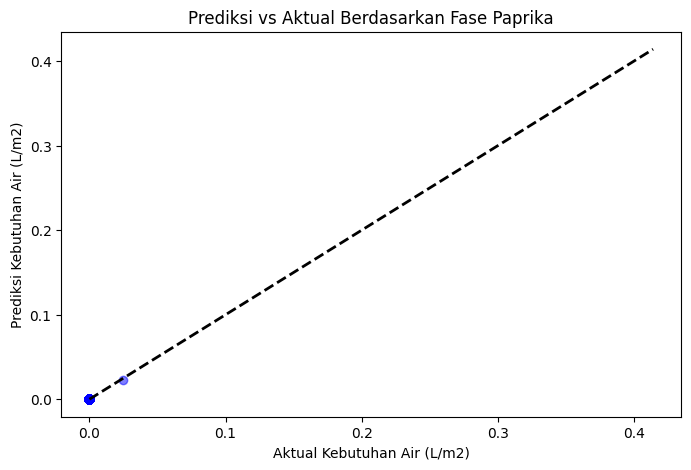

In [11]:
# Prediksi
y_pred = rf_model_air.predict(X_test)

# Hitung Metrik Error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f} L/m2")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} L/m2")
print(f"R-squared (R2): {r2:.4f}")

# Plot Prediksi vs Aktual
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Aktual Kebutuhan Air (L/m2)')
plt.ylabel('Prediksi Kebutuhan Air (L/m2)')
plt.title('Prediksi vs Aktual Berdasarkan Fase Paprika')
plt.show()

## simulasi

In [ ]:
# Dummy test dengan data NPK:
# Data 1: Suhu 25, Kelembapan 80, Tanah 60, Fase 0, N 150, P 60, K 230
# Data 2: Suhu 25, Kelembapan 80, Tanah 60, Fase 1, N 150, P 60, K 230

#! ['Suhu_Udara', 'Kelembapan_Udara', 'Kelembapan_Tanah', 'Fase', 'N', 'P', 'K']
data_simulasi = pd.DataFrame([
    [25.0, 80.0, 60.0, 0, 150.0, 60.0, 230.0], 
    [25.0, 80.0, 60.0, 1, 150.0, 60.0, 230.0]
], columns=features)

hasil_prediksi = rf_model_air.predict(data_simulasi)

print(f"Kebutuhan air Fase 0: {hasil_prediksi[0]:.3f} L/m2")
print(f"Kebutuhan air Fase 1: {hasil_prediksi[1]:.3f} L/m2")

# Export model
joblib.dump(rf_model_air, 'model/model_rf_air.pkl')
print("\nModel berhasil diexport!")

Kebutuhan air Fase 0: 0.371 L/m2
Kebutuhan air Fase 1: 0.371 L/m2

Model berhasil diexport!


Nentuin perhitungan durasi penyiraman pake : total air / debit pompa,    total air didapat dari output dari ai x luas lahan 